In [61]:
#Apply GAQQ on the antibiotic resistance project

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc

In [63]:
# read the 2021 data
catalog_data = pd.read_csv('/Users/wangyu/Desktop/Kang/Antibiotic resistance Forcast/resistance_forecast-main/data/derived_features/2021/2021_all_proteins_freq_details_proximity_aaindex_thermostability.csv')

In [64]:
# check the shape of catalog_data
catalog_data.shape

(4677, 15)

In [65]:
catalog_data = catalog_data.drop_duplicates()
print(catalog_data.shape)

(4677, 15)


In [66]:
#check confidence
catalog_data['confidence'].value_counts()

3) Uncertain significance     4303
2) Assoc w R - Interim         160
1) Assoc w R                   155
5) Not assoc w R                38
4) Not assoc w R - Interim      21
Name: confidence, dtype: int64

In [67]:
catalog_data.columns

Index(['gene', 'thermostability', 'Wildtype_AA', 'position', 'Mutated_AA',
       'one_letter_mutation', 'drug', 'confidence', 'delta_z', 'frequency',
       'phenotype', 'Proximity_to_R_Conferring', 'Nearest_Mutation_Index',
       'aa_index_dist', 'llr_score'],
      dtype='object')

In [68]:
# Count the number of NaN rows in the 'Proximity_to_R_Conferring' column for each unique gene
nan_frequency_count = catalog_data.groupby('gene')['llr_score'].apply(lambda x: x.isna().sum())

# Display the result
print(nan_frequency_count)

gene
Rv0678    0
atpE      0
ddn       0
embB      0
ethA      0
fgd1      0
gid       0
gyrA      0
gyrB      0
inhA      0
katG      0
pepQ      0
pncA      0
rplC      0
rpoB      0
rpsL      0
tlyA      0
Name: llr_score, dtype: int64


In [69]:
# Filter out category 3 entries
label_data = catalog_data[catalog_data['confidence'] != "3) Uncertain significance"]
print(label_data)

      gene  thermostability Wildtype_AA  position Mutated_AA  \
156    ddn       150.341615           L        49          P   
178   embB         1.766992           N        13          S   
212   embB         6.278201           L        74          R   
249   embB         1.157174           Q       139          H   
260   embB       122.171307           G       156          C   
...    ...              ...         ...       ...        ...   
4607  rpsL         8.368189           K        88          M   
4608  rpsL         7.045281           K        88          Q   
4629  tlyA       303.548442           L        74          P   
4665  tlyA        12.095898           G       232          D   
4668  tlyA         3.470052           N       236          K   

     one_letter_mutation drug                  confidence   delta_z  \
156                 L49P  DLM      2) Assoc w R - Interim  0.197001   
178                 N13S  EMB            5) Not assoc w R  0.013793   
212               

In [70]:
np.unique(label_data['confidence'].value_counts())

array([ 21,  38, 155, 160])

In [71]:
numeric_columns = ['Proximity_to_R_Conferring', 'aa_index_dist','llr_score','thermostability','frequency'] # frequency should be put at the last column if we gonna use GAQQ model
# Fill NaN values in the features with 0 or any suitable value
label_data[numeric_columns] = label_data[numeric_columns].fillna(0)

/var/folders/pf/drpv705s1dl6nzs53qkr38300000gn/T/ipykernel_74471/3140221259.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  label_data[numeric_columns] = label_data[numeric_columns].fillna(0)


In [72]:
# Extract the feature matrix and target vector
X_label = label_data[numeric_columns]
y_label= label_data['confidence']

In [73]:
X_label

,Proximity_to_R_Conferring,aa_index_dist,llr_score,thermostability,frequency
156,0.000000,49.271705,-2.555059,150.341615,0.833333
178,0.000000,19.571518,1.634181,1.766992,0.022831
212,23.102998,40.578571,1.784121,6.278201,0.720000
249,15.434290,22.559771,-1.680414,1.157174,0.010204
260,10.949380,41.869754,-6.696317,122.171307,0.659574
...,...,...,...,...,...
4607,15.135180,36.913725,-1.640230,8.368189,1.000000
4608,15.135180,20.152049,-0.460993,7.045281,0.636364
4629,8.125904,49.271705,0.050966,303.548442,1.000000
4665,11.049497,34.619038,-3.063160,12.095898,0.888889


In [74]:
print(X_label.shape, y_label.shape)

(374, 5) (374,)


In [75]:
np.unique(y_label)

array(['1) Assoc w R', '2) Assoc w R - Interim',
       '4) Not assoc w R - Interim', '5) Not assoc w R'], dtype=object)

In [76]:
# Convert the target variable to numeric labels
y_label = y_label.map({
    "1) Assoc w R": 1,
    "2) Assoc w R - Interim": 1,
    "4) Not assoc w R - Interim": 0, # change 2 to 1 to run the logistic regression
    "5) Not assoc w R": 0
})


In [77]:
y_label.value_counts()

1    315
0     59
Name: confidence, dtype: int64

In [78]:
# Standardize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Split the data into training and testing sets
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(X_scaled, y_label, test_size=0.3, random_state=42)

print(X_train_split)

[[ 0.29132597 -1.42676216  0.07860781 -0.35182914  0.02907233]
 [-0.41166331 -1.12695527 -0.30953942 -0.46306129  0.78680838]
 [ 3.67463787  2.14519439 -0.24022832 -0.39971931 -1.99455234]
 ...
 [-0.26034329 -1.01985338 -0.31436853  1.53159058  0.78680838]
 [-0.41153658  1.11502252  0.45266109 -0.41763671 -0.05882506]
 [-0.25710363  0.11031718  1.6668339  -0.46300746  0.78680838]]


In [79]:
print(y_train_split)

504     1
4237    1
2364    0
3743    1
499     1
       ..
1982    0
3635    1
4041    1
4228    1
3629    1
Name: confidence, Length: 261, dtype: int64


In [80]:
# Map confidence levels to phenotypes
def map_confidence_to_phenotype(confidence):
    if confidence in ['1) Assoc w R', '2) Assoc w R - Interim']:
        return 'Resistant'
    elif confidence in ['4) Not assoc w R - Interim', '5) Not assoc w R']:
        return 'Susceptible'
    else:
        return 'Unknown'
    
catalog_data['phenotype'] =catalog_data['confidence'].apply(map_confidence_to_phenotype)
catalog_data['phenotype'].value_counts()

Unknown        4303
Resistant       315
Susceptible      59
Name: phenotype, dtype: int64

In [81]:
catalog_data['confidence'].value_counts()

3) Uncertain significance     4303
2) Assoc w R - Interim         160
1) Assoc w R                   155
5) Not assoc w R                38
4) Not assoc w R - Interim      21
Name: confidence, dtype: int64

In [82]:
# In order to apply the GAQQ, the data would be seperated by this way:
X1 = X_train_split[y_train_split == 1]
X2 = X_train_split[y_train_split == 0]
X3 = X_test_split[y_test_split == 1]
X4 = X_test_split[y_test_split == 0]
# lambda is the penalty parameter
lambda1 = np.linspace(0.01, 5, 50)
lambda2 = np.linspace(0.01, 5, 50)


In [83]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri

# Activate the automatic conversion between pandas DataFrames and R data frames
pandas2ri.activate()
# Get the R global environment
r = ro.r
# Load the R script
try:
    r['source']("/Users/wangyu/Desktop/Kang/Robust_Regression/est.twoclass.R") # have to change the path
    print("R script loaded successfully.")
except Exception as e:
    print(f"Error loading R script: {e}")


R script loaded successfully.


In [84]:
# def check_invalid_values(matrix, name):
#     if np.any(np.isnan(matrix)):
#         print(f"{name} contains NaN values.")
#     if np.any(np.isinf(matrix)):
#         print(f"{name} contains Inf values.")
#     if not np.any(np.isnan(matrix)) and not np.any(np.isinf(matrix)):
#         print(f"{name} is free from NaN and Inf values.")

# check_invalid_values(X1, "X1")
# check_invalid_values(X2, "X2")

# Retrieve functions from the R global environment
SLDA_EBIC = ro.globalenv['SLDA.EBIC']
classify = ro.globalenv['classify']
# lambda1 = np.linspace(0.01, 1, 100)
# lambda2 = np.linspace(0.01, 10, 100)

# Call the R function and obtain the result of GAQQ model
result = SLDA_EBIC(X1, X2, lambda1, lambda2)
# Extract the C_opt matrix from the result
C_opt = np.array(result.rx2('C_opt'))  # get C_opt
print("Type of C_opt:", type(C_opt))
print("C_opt matrix:")
print(C_opt)
print("Condition number:", np.linalg.cond(C_opt))


Type of C_opt: <class 'numpy.ndarray'>
C_opt matrix:
[[ 1.93931701  0.          0.          0.          0.        ]
 [ 0.          0.91157554  0.         -0.09735794  0.        ]
 [ 0.          0.          0.89750508  0.          0.02850197]
 [ 0.         -0.09735794  0.          0.82468759  0.        ]
 [ 0.          0.          0.02850197  0.          1.85400859]]
Condition number: 2.5466384080874014


In [85]:
delta_h_opt = result.rx2('delta_h_opt')
print(delta_h_opt)

[-0.70845955  0.02046646 -0.08904289  0.          0.89059467]


In [86]:
epsilon = 1e-8  # use this to avoid singular
C_opt_regularized = C_opt + epsilon * np.eye(C_opt.shape[0])
C_opt_r = ro.r.matrix(C_opt_regularized, nrow=C_opt_regularized.shape[0], ncol=C_opt_regularized.shape[1])
ro.globalenv['C_opt'] = C_opt_r

# run classify function, could be regards as prediction function
try:
    pred_result = classify(X1, X2, X3, X4, C_opt_r, delta_h_opt)
    print("Classify completed successfully.")
except Exception as e:
    print(f"Error during classify with regularized C_opt: {e}")

y_hat = np.array(pred_result.rx2('y_hat'))
error = pred_result.rx2('error')[0]
rmse = pred_result.rx2('rmse')[0]
est_label = np.array(pred_result.rx2('est_label'))


Classify completed successfully.


In [87]:
print(y_hat) # this is the estimation of frequency

[ 0.28796851 -1.50429496  0.29764075  0.30915225  0.27996169  0.2930882
  0.30633118  0.28404382  0.28093313  0.30284139  0.2910219   0.30071915
  0.29718497  0.31370058  0.29812033  0.31655693  0.36055651  0.30681308
  0.34181405  0.30649957  0.3280785   0.31080482  0.30157158 -1.47753895
  0.33284562  0.32426838  0.30355128  0.2969582   0.29093133  0.28221028
  0.293638    0.30460122  0.31479821  0.30198057  0.30159901  0.29062197
  0.30970903  0.29100639  0.3040412   0.30915225  0.30056318  0.2777367
  0.29949388  0.31394659  0.31517607  0.29556419  0.28344999  0.29192532
  0.29094897  0.29671293  0.31925109  0.32216052  0.28367731  0.29669361
  0.30520685  0.28344999  0.29273989  0.29549361  0.30212659 -1.46164652
  0.28833396  0.29680647 -1.48359381  0.29526842 -1.50611151  0.2982864
  0.30488986  0.30296289  0.30322187  0.29068641  0.2963969   0.29308005
  0.255805    0.29258506  0.30213641  0.29312902  0.22870706  0.26686828
  0.31578903  0.29886564 -1.50057953  0.28649936  0.29

In [88]:
print(rmse) # rmse of frequency in the 2021 test set

0.8911922077958636


In [89]:
# cuaculate the classification result on the test set
y_pred = 1 - est_label
correct_predictions = y_pred == y_test_split
accuracy = np.mean(correct_predictions)
print(accuracy) 

0.7168141592920354


Make the prediction on the 2023 changed data

In [90]:
import pandas as pd

# Load the 2021 and 2023 datasets
file_2021 = "/Users/wangyu/Desktop/Kang/Antibiotic resistance Forcast/resistance_forecast-main/data/derived_features/2021/2021_all_proteins_freq_details_proximity_aaindex_thermostability.csv"
file_2023 = "/Users/wangyu/Desktop/Kang/Antibiotic resistance Forcast/resistance_forecast-main/data/derived_features/all_proteins_freq_details_proximity_aaindex_thermostabilit.csv"

df_2021 = pd.read_csv(file_2021)
df_2023 = pd.read_csv(file_2023)


In [91]:
# Merge the two datasets on gene, Wildtype_AA, position, Mutated_AA
merged_df = pd.merge(
    df_2021,
    df_2023,
    on=['gene', 'one_letter_mutation'],
    suffixes=('_2021', '_2023')
)
merged_df=merged_df.drop_duplicates()

In [92]:

# Filter rows where confidence remained unchanged in category 3
unchanged_category_3 = merged_df[
    (merged_df['confidence_2021'] == "3) Uncertain significance") &
    (merged_df['confidence_2023'] == "3) Uncertain significance")
]
unchanged_category_3 = unchanged_category_3.drop_duplicates()

# Count the number of positions where the confidence remained unchanged
num_unchanged = unchanged_category_3.shape[0]

print(f"Number of positions where confidence remained unchanged in category 3: {num_unchanged}")

# Optionally, preview the unchanged rows
display(unchanged_category_3[['gene', 'one_letter_mutation', 'confidence_2021', 'confidence_2023']])

Number of positions where confidence remained unchanged in category 3: 5164


,gene,one_letter_mutation,confidence_2021,confidence_2023
0,Rv0678,S2I,3) Uncertain significance,3) Uncertain significance
1,Rv0678,S2I,3) Uncertain significance,3) Uncertain significance
2,Rv0678,S2I,3) Uncertain significance,3) Uncertain significance
3,Rv0678,S2I,3) Uncertain significance,3) Uncertain significance
4,Rv0678,S2R,3) Uncertain significance,3) Uncertain significance
...,...,...,...,...
5693,tlyA,R244P,3) Uncertain significance,3) Uncertain significance
5694,tlyA,A250T,3) Uncertain significance,3) Uncertain significance
5695,tlyA,R249Q,3) Uncertain significance,3) Uncertain significance
5696,tlyA,S252L,3) Uncertain significance,3) Uncertain significance


In [93]:
# Exclude rows where confidence is "3) Uncertain significance" in both files
filtered_df = merged_df[
    ~((merged_df['confidence_2021'] == "3) Uncertain significance") &
      (merged_df['confidence_2023'] == "3) Uncertain significance"))
]

# Identify rows where confidence values differ between 2021 and 2023
updated_confidence = filtered_df[
    filtered_df['confidence_2021'] != filtered_df['confidence_2023']
]

In [94]:
print(merged_df.shape,filtered_df.shape,updated_confidence.shape)

(5698, 28) (534, 28) (169, 28)


In [95]:
filtered_df=filtered_df.drop_duplicates()

In [96]:
filtered_df['confidence_2021'].value_counts()

1) Assoc w R                  170
2) Assoc w R - Interim        169
3) Uncertain significance     111
5) Not assoc w R               59
4) Not assoc w R - Interim     25
Name: confidence_2021, dtype: int64

In [97]:
filtered_df['confidence_2023'].value_counts()

2) Assoc w R - Interim        220
1) Assoc w R                  207
5) Not assoc w R               65
4) Not assoc w R - Interim     25
3) Uncertain significance      17
Name: confidence_2023, dtype: int64

In [98]:
# Check for rows where confidence is 3 in both 2021 and 2023
confidence_3_in_both = filtered_df[
    (filtered_df['confidence_2021'] == "3) Uncertain significance") &
    (filtered_df['confidence_2023'] == "3) Uncertain significance")
]

# Display the result
print(f"Number of rows with confidence 3 in both 2021 and 2023: {confidence_3_in_both.shape[0]}")
print(confidence_3_in_both)

Number of rows with confidence 3 in both 2021 and 2023: 0
Empty DataFrame
Columns: [gene, thermostability_2021, Wildtype_AA_2021, position_2021, Mutated_AA_2021, one_letter_mutation, drug_2021, confidence_2021, delta_z_2021, frequency_2021, phenotype_2021, Proximity_to_R_Conferring_2021, Nearest_Mutation_Index_2021, aa_index_dist_2021, llr_score_2021, thermostability_2023, Wildtype_AA_2023, position_2023, Mutated_AA_2023, drug_2023, confidence_2023, delta_z_2023, frequency_2023, phenotype_2023, Proximity_to_R_Conferring_2023, Nearest_Mutation_Index_2023, aa_index_dist_2023, llr_score_2023]
Index: []

[0 rows x 28 columns]


In [99]:
# Filter for confidence_2021 == "3) Uncertain significance" that changed to other categories
confidence_3_changed = filtered_df[
    (filtered_df['confidence_2021'] == "3) Uncertain significance") &
    (filtered_df['confidence_2023'] != "3) Uncertain significance")
]
confidence_3_changed = confidence_3_changed.drop_duplicates(subset=['gene', 'one_letter_mutation','confidence_2021','confidence_2023'])
# Count value occurrences in confidence_2023
changed_counts = confidence_3_changed['confidence_2023'].value_counts()

# Display the result
print(f"Number of mutations with confidence 3 in 2021 that changed to other categories in 2023: {confidence_3_changed.shape[0]}")
print("Value counts of the changed categories in 2023:")
print(changed_counts)

Number of mutations with confidence 3 in 2021 that changed to other categories in 2023: 81
Value counts of the changed categories in 2023:
2) Assoc w R - Interim        55
1) Assoc w R                  15
5) Not assoc w R               6
4) Not assoc w R - Interim     5
Name: confidence_2023, dtype: int64


In [100]:
# Convert the target var 
 

mapping = {
    "1) Assoc w R": 1,
    "2) Assoc w R - Interim": 1,
    "4) Not assoc w R - Interim": 0,
    "5) Not assoc w R": 0,
}

confidence_3_changed['confidence_2023'] = confidence_3_changed['confidence_2023'].map(mapping)

print(confidence_3_changed[['confidence_2021', 'confidence_2023']])
print(confidence_3_changed['confidence_2023'].unique())

                confidence_2021  confidence_2023
57    3) Uncertain significance                1
61    3) Uncertain significance                1
82    3) Uncertain significance                1
134   3) Uncertain significance                1
136   3) Uncertain significance                1
...                         ...              ...
4970  3) Uncertain significance                1
4972  3) Uncertain significance                0
4978  3) Uncertain significance                1
4991  3) Uncertain significance                1
4993  3) Uncertain significance                1

[81 rows x 2 columns]
[1 0]


In [101]:
# Step 0: Remove duplicates from both DataFrames
catalog_data = catalog_data.drop_duplicates(subset=['gene', 'one_letter_mutation','confidence'])
# confidence_3_changed = confidence_3_changed.drop_duplicates(subset=['gene', 'one_letter_mutation'])

# Step 1: Select mutation positions from confidence_3_changed
selected_positions = confidence_3_changed[['gene', 'one_letter_mutation', 'confidence_2023']]

# Step 2: Filter category_3_data to match the selected positions
category_3_data = catalog_data[catalog_data['confidence'] == "3) Uncertain significance"]
category_3_data = category_3_data.merge(selected_positions, on=['gene', 'one_letter_mutation'], how='inner')

# Check the shape
print(f"Shape of filtered category_3_data after dropping duplicates: {category_3_data.shape}")

Shape of filtered category_3_data after dropping duplicates: (81, 16)


In [102]:
# Step 1: Select mutation positions from confidence_3_changed (use one_letter_mutation_2021)
selected_positions = confidence_3_changed[['gene', 'one_letter_mutation', 'confidence_2023']]
# Step 2: Filter category_3_data to match the selected positions
category_3_data = catalog_data[catalog_data['confidence'] == "3) Uncertain significance"]
category_3_data = category_3_data.merge(selected_positions, on=['gene', 'one_letter_mutation'], how='inner')

In [103]:
# Step 3: Prepare data for prediction
category_3_data[numeric_columns] = category_3_data[numeric_columns].fillna(0)  # Handle missing values
X_category_3 = category_3_data[numeric_columns]



In [104]:
# Step 4: Make predictions for the filtered data using GAQQ model

In [105]:
pred_result = classify(X1, X2, X3, X4, C_opt_r, delta_h_opt)

In [106]:
# epsilon = 1e-8  # use this to avoid singular
# C_opt_regularized = C_opt + epsilon * np.eye(C_opt.shape[0])
# C_opt_r = ro.r.matrix(C_opt_regularized, nrow=C_opt_regularized.shape[0], ncol=C_opt_regularized.shape[1])
# ro.globalenv['C_opt'] = C_opt_r

# # run classify function
# try:
#     pred_result = classify(X1, X2, X3, X4, C_opt_r, delta_h_opt)
#     print("Classify completed successfully.")
# except Exception as e:
#     print(f"Error during classify with regularized C_opt: {e}")

# y_hat = np.array(pred_result.rx2('y_hat'))
# error = pred_result.rx2('error')[0]
# rmse = pred_result.rx2('rmse')[0]
# est_label = np.array(pred_result.rx2('est_label'))

Classify completed successfully.


In [108]:
# # cuaculate the classification result
# y_pred = 1 - est_label
# correct_predictions = y_pred == y_test_split
# accuracy = np.mean(correct_predictions)
# print(accuracy)

0.7168141592920354


In [109]:
# rmse

0.8911922077958636

In [110]:
X3 =X_category_3[category_3_data['confidence_2023'] == 1]
X4 = X_category_3[category_3_data['confidence_2023']== 0]
pred_result = classify(X1, X2, X3, X4, C_opt_r, delta_h_opt)
y_hat = np.array(pred_result.rx2('y_hat'))
error = pred_result.rx2('error')[0]
rmse = pred_result.rx2('rmse')[0]
est_label = np.array(pred_result.rx2('est_label'))
y_pred=1-est_label

In [111]:

rmse # rmse of frequency 

1.3399603737141197

In [113]:
error # error of classification

30.0

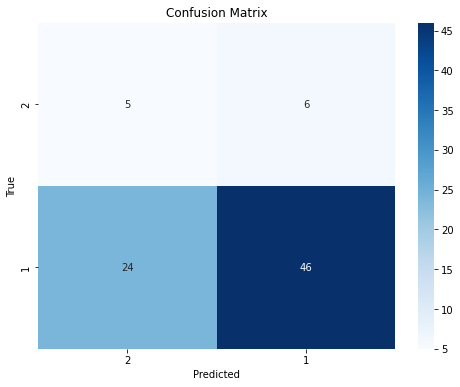

In [114]:
cm = confusion_matrix(category_3_data['confidence_2023'],  y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[2, 1], yticklabels=[2, 1])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [115]:
print(classification_report(category_3_data['confidence_2023'], y_pred ))

              precision    recall  f1-score   support

           0       0.17      0.45      0.25        11
           1       0.88      0.66      0.75        70

    accuracy                           0.63        81
   macro avg       0.53      0.56      0.50        81
weighted avg       0.79      0.63      0.69        81

